In [111]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [112]:
weight = 0.5
bias = 0.5

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


In [113]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.5000],
         [0.5100],
         [0.5200],
         [0.5300],
         [0.5400],
         [0.5500],
         [0.5600],
         [0.5700],
         [0.5800],
         [0.5900]]))

In [114]:
# train test split
# length = int(len(X)*0.7) #70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [115]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
  plt.figure(figsize=(10, 7))

  plt.scatter(train_data,train_labels, c='b', s=4, label='Training data')
  plt.scatter(test_data, test_labels, c='g', s= 4, label='Testing data')

  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

  plt.legend(prop={"size":14});

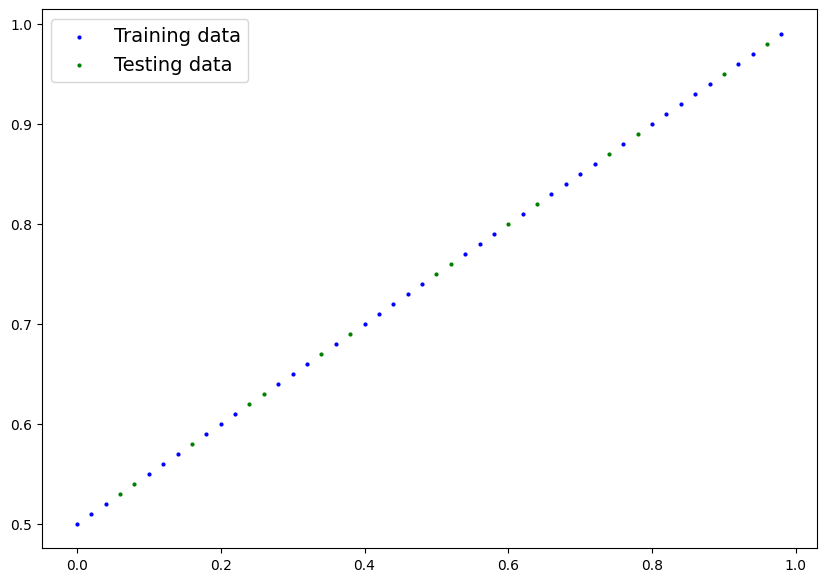

In [116]:
plot_predictions(X_train, y_train,X_test,y_test)

In [117]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [118]:
# fitting the model

torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [119]:
# making predicitions

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds


tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568],
        [0.2096],
        [0.1557],
        [0.3780],
        [0.1827],
        [0.1490]])

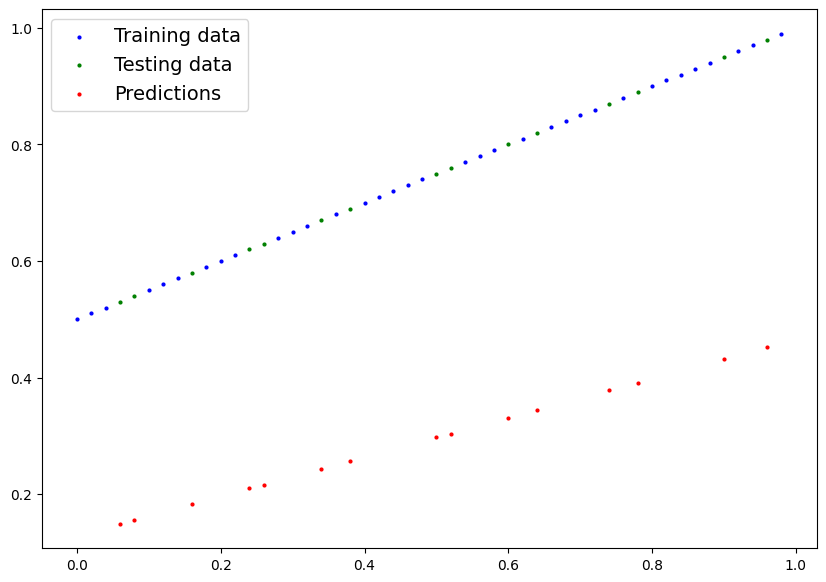

In [120]:
plot_predictions(X_train, y_train,X_test,y_test, predictions=y_preds)

In [121]:
y_test - y_preds



tensor([[0.4137],
        [0.4986],
        [0.4692],
        [0.5182],
        [0.4267],
        [0.5280],
        [0.4561],
        [0.4528],
        [0.4757],
        [0.4332],
        [0.4104],
        [0.3843],
        [0.4920],
        [0.3973],
        [0.3810]])

In [122]:
# Training our model

#creat a loss function
loss_fn = nn.L1Loss() # <- this is the MAE(mean absolute error)

#optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [127]:
torch.manual_seed(42)

epochs = 100


for epoch in range(epochs):
  model_0.train()

  y_pred = model_0(X_train) # Get predictions on training data

  loss = loss_fn(y_pred, y_train) # Calculate loss using training predictions and training labels
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()

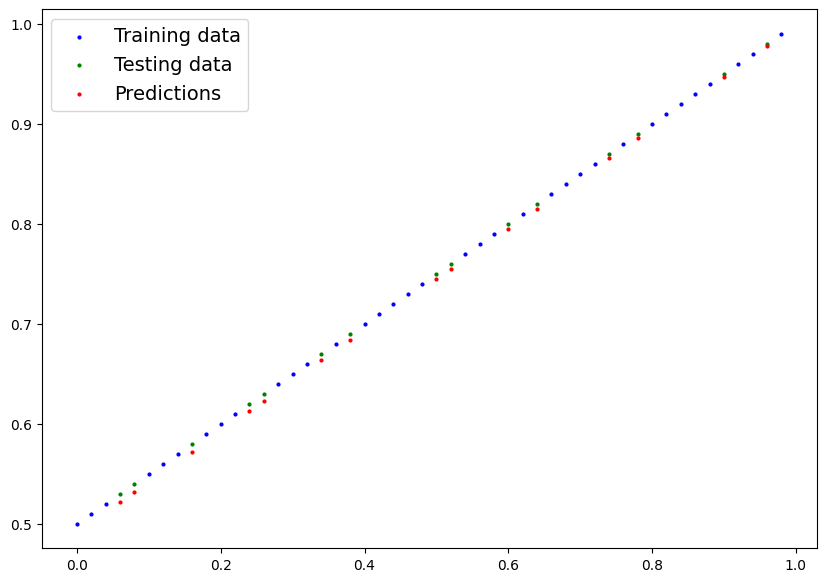

In [128]:
plot_predictions(X_train, y_train,X_test,y_test, predictions=y_preds)

In [129]:
model_0.eval()

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.6228],
        [0.8862],
        [0.7950],
        [0.9470],
        [0.6633],
        [0.9774],
        [0.7545],
        [0.7444],
        [0.8153],
        [0.6836],
        [0.6127],
        [0.5316],
        [0.8659],
        [0.5721],
        [0.5215]])

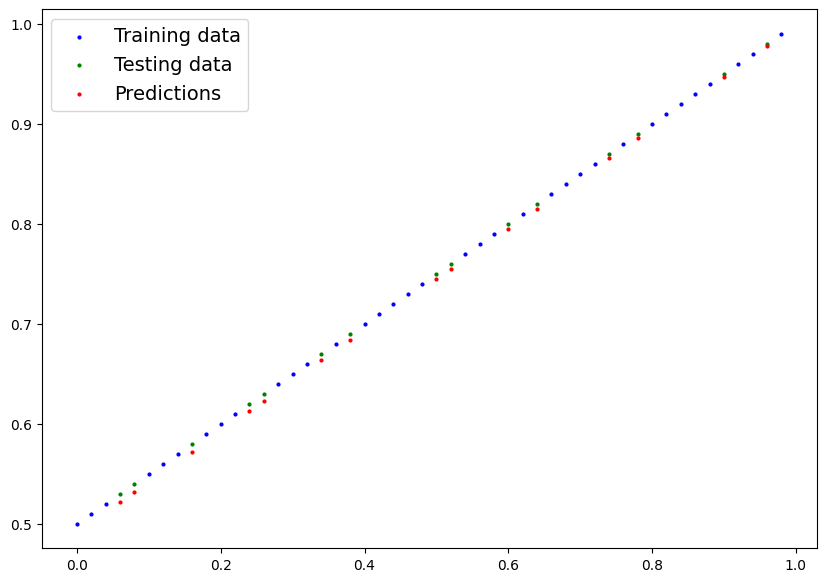

In [130]:
plot_predictions(X_train, y_train,X_test,y_test, predictions=y_preds)